# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ravikiranbathe/flyrank-ai/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [34]:
# Capstone research question and decision

research_question = (
    "Can search-performance signals be used to identify and rank "
    "content pages that are strong candidates for review or refresh?"
)

decision = (
    "Which pages should be reviewed first for refresh, expansion, "
    "protection, pruning, or monitoring?"
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision)

Research question:
Can search-performance signals be used to identify and rank content pages that are strong candidates for review or refresh?

Decision supported:
Which pages should be reviewed first for refresh, expansion, protection, pruning, or monitoring?


### Research question

Can search-performance signals be used to identify and rank content pages that are strong candidates for review or refresh?

### Decision supported

The analysis is intended to help prioritize which pages should be reviewed first for refresh, expansion, protection, pruning, or monitoring.

The output is decision-support rather than a guarantee that refreshing a page will improve its future performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [35]:
%pip -q install duckdb huggingface_hub

In [36]:
import os, getpass

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass(
    "Paste your Hugging Face READ token (hf_...): "
)

In [37]:
import duckdb

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

print("Connected to FlyRank full warehouse.")
print("Tables configured:", list(TABLES.keys()))

Connected to FlyRank full warehouse.
Tables configured: ['dim_clients', 'dim_content', 'fact_daily', 'fact_query_90d']


In [38]:
# Inspect the available warehouse date range

date_info = con.sql(f"""
    SELECT
        MIN(report_date) AS earliest_date,
        MAX(report_date) AS latest_date,
        COUNT(DISTINCT report_date) AS number_of_days
    FROM {TABLES['fact_daily']}
""").df()

display(date_info)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,earliest_date,latest_date,number_of_days
0,2025-01-27,2026-06-30,520


In [39]:
# Check client history before choosing the prediction window

client_history = con.sql(f"""
    SELECT
        client_hash_id,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date,
        COUNT(DISTINCT report_date) AS days_available
    FROM {TABLES['fact_daily']}
    GROUP BY client_hash_id
    ORDER BY first_date
""").df()

print("Number of clients:", len(client_history))
print("\nClient history summary:")
display(client_history.describe(include="all"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Number of clients: 70

Client history summary:


,client_hash_id,first_date,last_date,days_available
count,70,70,70,70.000000
unique,70,NaN,NaN,NaN
top,client_ff644d8251367cbb,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,2025-11-14 13:22:17.142857,2026-06-22 00:20:34.285714,215.271429
min,NaN,2025-01-27 00:00:00,2026-02-23 00:00:00,34.000000
25%,NaN,2025-09-24 00:00:00,2026-06-30 00:00:00,114.000000
50%,NaN,2025-11-05 00:00:00,2026-06-30 00:00:00,233.000000
75%,NaN,2026-02-19 00:00:00,2026-06-30 00:00:00,278.000000
max,NaN,2026-05-28 00:00:00,2026-06-30 00:00:00,520.000000


In [40]:
# Build a leakage-safe prediction dataset
# Features = previous 30 days
# Label = following 30 days

prediction_data = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS latest_date
        FROM {TABLES['fact_daily']}
    ),

    monthly AS (
        SELECT
            client_hash_id,
            content_hash_id,

            SUM(
                CASE
                    WHEN report_date > latest_date - INTERVAL 60 DAY
                     AND report_date <= latest_date - INTERVAL 30 DAY
                    THEN gsc_impressions
                    ELSE 0
                END
            ) AS impressions_prev30,

            SUM(
                CASE
                    WHEN report_date > latest_date - INTERVAL 30 DAY
                     AND report_date <= latest_date
                    THEN gsc_impressions
                    ELSE 0
                END
            ) AS impressions_last30

        FROM {TABLES['fact_daily']}, bounds
        WHERE report_date > latest_date - INTERVAL 60 DAY
        GROUP BY client_hash_id, content_hash_id
    )

    SELECT *
    FROM monthly
    WHERE impressions_prev30 >= 100
""").df()

print("Prediction dataset shape:", prediction_data.shape)
display(prediction_data.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Prediction dataset shape: (111247, 4)


,client_hash_id,content_hash_id,impressions_prev30,impressions_last30
0,client_3ffa76342f366962,content_bdc656fc8f037ac0,173.0,124.0
1,client_3ffa76342f366962,content_315f75aa07a662bf,139.0,48.0
2,client_e547b89c05043229,content_ded3d63f83e7a4cf,588.0,1795.0
3,client_e547b89c05043229,content_b3a828afc221c27a,115.0,85.0
4,client_e547b89c05043229,content_0252039a1f263e4e,352.0,299.0


In [41]:
# Define the future-looking outcome
# Positive label = impressions declined by 20% or more

prediction_data["is_declining"] = (
    prediction_data["impressions_last30"]
    < 0.80 * prediction_data["impressions_prev30"]
).astype(int)

print("Prediction dataset shape:", prediction_data.shape)
print("\nDeclining pages:")
print(prediction_data["is_declining"].value_counts())

print("\nDeclining rate:")
print(round(prediction_data["is_declining"].mean(), 4))

Prediction dataset shape: (111247, 5)

Declining pages:
is_declining
1    71547
0    39700
Name: count, dtype: int64

Declining rate:
0.6431


In [42]:
# Validate the future-decline label

print("Previous 30-day impressions:")
display(prediction_data["impressions_prev30"].describe())

print("\nFuture 30-day impressions:")
display(prediction_data["impressions_last30"].describe())

print("\nDecline rate by minimum previous-impression threshold:")

for threshold in [100, 500, 1000, 5000]:
    subset = prediction_data[
        prediction_data["impressions_prev30"] >= threshold
    ]

    if len(subset) > 0:
        print(
            f"Threshold >= {threshold:>5}: "
            f"{len(subset):>7,} pages | "
            f"decline rate = {subset['is_declining'].mean():.3f}"
        )

Previous 30-day impressions:


,impressions_prev30
count,111247.000000
mean,2290.660665
std,6942.053859
min,100.000000
25%,231.000000
50%,565.000000
75%,1801.000000
max,585502.000000



Future 30-day impressions:


,impressions_last30
count,111247.000000
mean,1837.639595
std,6770.709487
min,0.000000
25%,131.000000
50%,388.000000
75%,1292.000000
max,615012.000000



Decline rate by minimum previous-impression threshold:
Threshold >=   100: 111,247 pages | decline rate = 0.643
Threshold >=   500:  59,196 pages | decline rate = 0.647
Threshold >=  1000:  40,555 pages | decline rate = 0.647
Threshold >=  5000:  11,061 pages | decline rate = 0.627


In [43]:
# Check whether zero future impressions are driving the decline label

zero_future = (
    prediction_data["impressions_last30"] == 0
).sum()

print("Pages with zero future impressions:", f"{zero_future:,}")
print(
    "Share of pages with zero future impressions:",
    f"{zero_future / len(prediction_data):.3%}"
)

print("\nFuture impressions among declining pages:")
display(
    prediction_data.loc[
        prediction_data["is_declining"] == 1,
        "impressions_last30"
    ].describe()
)

Pages with zero future impressions: 1,160
Share of pages with zero future impressions: 1.043%

Future impressions among declining pages:


,impressions_last30
count,71547.000000
mean,1056.275553
std,3512.210493
min,0.000000
25%,78.000000
50%,227.000000
75%,753.000000
max,171606.000000


In [44]:
# Prepare leakage-safe model features

# Baseline: simple prior-performance rule
prediction_data["baseline_score"] = 0

prediction_data.loc[
    prediction_data["impressions_prev30"] >= 1000,
    "baseline_score"
] += 1

prediction_data.loc[
    prediction_data["impressions_prev30"] >= 5000,
    "baseline_score"
] += 1

# Baseline prediction:
# flag pages with relatively strong prior visibility as review candidates
prediction_data["baseline_pred"] = (
    prediction_data["baseline_score"] >= 1
).astype(int)

# Leakage-safe features: all come from the period before the future outcome
feature_cols = [
    "impressions_prev30"
]

model_data = prediction_data.dropna(
    subset=feature_cols + ["is_declining"]
).copy()

print("Model dataset:", model_data.shape)
print("Features:", feature_cols)
print("Positive rate:", round(model_data["is_declining"].mean(), 4))

Model dataset: (111247, 7)
Features: ['impressions_prev30']
Positive rate: 0.6431


In [45]:
# Inspect the full-warehouse table schemas

print("DIM_CONTENT columns:")
display(
    con.sql(f"""
        DESCRIBE SELECT * FROM {TABLES['dim_content']}
    """).df()
)

print("\nDAILY PERFORMANCE columns:")
display(
    con.sql(f"""
        DESCRIBE SELECT * FROM {TABLES['fact_daily']}
    """).df()
)

DIM_CONTENT columns:


,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,keyword_hash_id,VARCHAR,YES,None,None,None
3,url_hash_id,VARCHAR,YES,None,None,None
4,keyword_char_count,BIGINT,YES,None,None,None
5,keyword_token_count,BIGINT,YES,None,None,None
6,url_char_count,BIGINT,YES,None,None,None
7,content_created_date,DATE,YES,None,None,None
8,content_updated_date,DATE,YES,None,None,None
9,content_type,VARCHAR,YES,None,None,None



DAILY PERFORMANCE columns:


,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [46]:
# Build leakage-safe features from the period BEFORE the future outcome

feature_data = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS latest_date
        FROM {TABLES['fact_daily']}
    ),

    daily_agg AS (
        SELECT
            f.client_hash_id,
            f.content_hash_id,

            -- Previous 30 days: May 2-31 relative to the final June outcome
            SUM(
                CASE
                    WHEN f.report_date > b.latest_date - INTERVAL 60 DAY
                     AND f.report_date <= b.latest_date - INTERVAL 30 DAY
                    THEN f.gsc_impressions ELSE 0
                END
            ) AS impressions_prev30,

            SUM(
                CASE
                    WHEN f.report_date > b.latest_date - INTERVAL 60 DAY
                     AND f.report_date <= b.latest_date - INTERVAL 30 DAY
                    THEN f.gsc_clicks ELSE 0
                END
            ) AS clicks_prev30,

            AVG(
                CASE
                    WHEN f.report_date > b.latest_date - INTERVAL 60 DAY
                     AND f.report_date <= b.latest_date - INTERVAL 30 DAY
                    THEN f.gsc_avg_position
                END
            ) AS avg_position_prev30,

            -- 30 days before the feature window
            SUM(
                CASE
                    WHEN f.report_date > b.latest_date - INTERVAL 90 DAY
                     AND f.report_date <= b.latest_date - INTERVAL 60 DAY
                    THEN f.gsc_impressions ELSE 0
                END
            ) AS impressions_prev_prev30,

            -- 90-day visibility ending at the feature boundary
            SUM(
                CASE
                    WHEN f.report_date > b.latest_date - INTERVAL 120 DAY
                     AND f.report_date <= b.latest_date - INTERVAL 30 DAY
                    THEN f.gsc_impressions ELSE 0
                END
            ) AS impressions_90d

        FROM {TABLES['fact_daily']} f
        CROSS JOIN bounds b

        WHERE f.report_date > b.latest_date - INTERVAL 120 DAY
          AND f.report_date <= b.latest_date - INTERVAL 30 DAY

        GROUP BY
            f.client_hash_id,
            f.content_hash_id
    )

    SELECT
        d.*,

        c.content_created_date,
        c.content_updated_date,
        c.word_count,
        c.content_type,

        DATE_DIFF(
            'day',
            c.content_created_date,
            (SELECT latest_date - INTERVAL 30 DAY FROM bounds)
        ) AS content_age_days,

        DATE_DIFF(
            'day',
            c.content_updated_date,
            (SELECT latest_date - INTERVAL 30 DAY FROM bounds)
        ) AS days_since_last_update

    FROM daily_agg d

    LEFT JOIN {TABLES['dim_content']} c
      ON d.client_hash_id = c.client_hash_id
     AND d.content_hash_id = c.content_hash_id

    WHERE d.impressions_prev30 >= 100
""").df()

# Derive pre-outcome metrics
feature_data["ctr_prev30"] = (
    feature_data["clicks_prev30"]
    / feature_data["impressions_prev30"]
    * 100
)

feature_data["trend_pct"] = (
    (feature_data["impressions_prev30"] - feature_data["impressions_prev_prev30"])
    / feature_data["impressions_prev_prev30"].replace(0, float("nan"))
    * 100
)

print("Feature table shape:", feature_data.shape)
print("\nFeature columns:")
print(feature_data.columns.tolist())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature table shape: (111247, 15)

Feature columns:
['client_hash_id', 'content_hash_id', 'impressions_prev30', 'clicks_prev30', 'avg_position_prev30', 'impressions_prev_prev30', 'impressions_90d', 'content_created_date', 'content_updated_date', 'word_count', 'content_type', 'content_age_days', 'days_since_last_update', 'ctr_prev30', 'trend_pct']


In [47]:
# Attach the future outcome to the leakage-safe feature table

labels = prediction_data[
    ["client_hash_id", "content_hash_id", "is_declining"]
].copy()

model_data = feature_data.merge(
    labels,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Final modeling dataset:", model_data.shape)

print("\nTarget distribution:")
print(model_data["is_declining"].value_counts())

print("\nTarget rate:")
print(round(model_data["is_declining"].mean(), 4))

print("\nMissing values in candidate features:")
display(
    model_data[
        [
            "impressions_prev30",
            "clicks_prev30",
            "avg_position_prev30",
            "impressions_prev_prev30",
            "impressions_90d",
            "content_age_days",
            "days_since_last_update",
            "ctr_prev30",
            "trend_pct"
        ]
    ].isna().sum()
)

Final modeling dataset: (111247, 16)

Target distribution:
is_declining
1    71547
0    39700
Name: count, dtype: int64

Target rate:
0.6431

Missing values in candidate features:


,0
impressions_prev30,0
clicks_prev30,0
avg_position_prev30,0
impressions_prev_prev30,0
impressions_90d,0
content_age_days,0
days_since_last_update,0
ctr_prev30,0
trend_pct,9267


In [48]:
# Investigate missing trend_pct values

missing_trend = model_data["trend_pct"].isna()

print("Rows with missing trend_pct:", missing_trend.sum())
print(
    "Rows with non-zero previous-period impressions:",
    (
        model_data.loc[missing_trend, "impressions_prev_prev30"] > 0
    ).sum()
)
print(
    "Rows with zero previous-period impressions:",
    (
        model_data.loc[missing_trend, "impressions_prev_prev30"] == 0
    ).sum()
)

print("\nPrevious-period impressions for missing trend:")
display(
    model_data.loc[
        missing_trend,
        "impressions_prev_prev30"
    ].describe()
)

Rows with missing trend_pct: 9267
Rows with non-zero previous-period impressions: 0
Rows with zero previous-period impressions: 9267

Previous-period impressions for missing trend:


,impressions_prev_prev30
count,9267.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [49]:
# Final leakage-safe feature set for the first model

feature_cols = [
    "impressions_prev30",
    "clicks_prev30",
    "avg_position_prev30",
    "impressions_prev_prev30",
    "impressions_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr_prev30"
]

model_data = model_data.dropna(
    subset=feature_cols + ["is_declining"]
).copy()

print("Final model dataset:", model_data.shape)
print("\nFeatures used:")
for feature in feature_cols:
    print("-", feature)

print("\nTarget rate:", round(model_data["is_declining"].mean(), 4))

Final model dataset: (111247, 16)

Features used:
- impressions_prev30
- clicks_prev30
- avg_position_prev30
- impressions_prev_prev30
- impressions_90d
- content_age_days
- days_since_last_update
- ctr_prev30

Target rate: 0.6431


In [50]:
# Week-7 baseline recreated with leakage-safe pre-outcome measurements
# This is a review-priority heuristic, not a prediction guarantee.

# Recalculate pre-period trend
model_data["trend_pct_baseline"] = (
    (
        model_data["impressions_prev30"]
        - model_data["impressions_prev_prev30"]
    )
    / model_data["impressions_prev_prev30"].replace(0, float("nan"))
    * 100
)

model_data["baseline_score"] = 0

# 1. Content age
model_data.loc[
    model_data["content_age_days"] >= 365,
    "baseline_score"
] += 40

# 2. Declining trend
model_data.loc[
    model_data["trend_pct_baseline"] < -10,
    "baseline_score"
] += 25

# 3. Low CTR
model_data.loc[
    model_data["ctr_prev30"] < 2,
    "baseline_score"
] += 20

# 4. Meaningful visibility
model_data.loc[
    model_data["impressions_prev30"] >= 1000,
    "baseline_score"
] += 15

# Baseline decision
model_data["baseline_pred"] = (
    model_data["baseline_score"] >= 60
).astype(int)

print("Baseline positive rate:",
      round(model_data["baseline_pred"].mean(), 4))

print("\nBaseline prediction counts:")
print(model_data["baseline_pred"].value_counts())

print("\nActual future-decline rate:",
      round(model_data["is_declining"].mean(), 4))

Baseline positive rate: 0.3091

Baseline prediction counts:
baseline_pred
0    76858
1    34389
Name: count, dtype: int64

Actual future-decline rate: 0.6431


In [51]:
# Honest client-grouped train/test split

from sklearn.model_selection import GroupShuffleSplit

X = model_data[feature_cols]
y = model_data["is_declining"]
groups = model_data["client_hash_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", groups.iloc[train_idx].nunique())
print("Test clients:", groups.iloc[test_idx].nunique())

print("\nTraining decline rate:",
      round(y_train.mean(), 4))

print("Test decline rate:",
      round(y_test.mean(), 4))

Training rows: 97494
Test rows: 13753
Training clients: 40
Test clients: 10

Training decline rate: 0.6417
Test decline rate: 0.6535


In [52]:
# Train the first ML model on the honest client-grouped split

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [53]:
# Evaluate the Random Forest on the untouched client-grouped test set

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

rf_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "Average Precision": average_precision_score(y_test, y_prob)
}

print("Random Forest results:")
for metric, value in rf_results.items():
    print(f"{metric}: {value:.4f}")

Random Forest results:
Accuracy: 0.6961
Precision: 0.7412
Recall: 0.8220
F1: 0.7795
Average Precision: 0.7619


In [54]:
# Evaluate the Week-7 baseline on the exact same test set

baseline_test = model_data.iloc[test_idx]["baseline_pred"]

baseline_results = {
    "Accuracy": accuracy_score(y_test, baseline_test),
    "Precision": precision_score(y_test, baseline_test),
    "Recall": recall_score(y_test, baseline_test),
    "F1": f1_score(y_test, baseline_test)
}

print("Week-7 baseline results:")
for metric, value in baseline_results.items():
    print(f"{metric}: {value:.4f}")

Week-7 baseline results:
Accuracy: 0.4240
Precision: 0.7092
Recall: 0.2010
F1: 0.3133


### Data

This capstone uses the FlyRank pseudonymized full warehouse release rather than the 30,000-row starter CSV.

The warehouse contains daily content-performance records from **2025-01-27 through 2026-06-30**, covering 520 distinct report dates in this run.

The main tables used are:

- `fact_content_daily_performance` — daily content-level performance signals
- `dim_content` — content metadata used to derive content-age and update-age features

The analysis uses a feature window preceding the outcome window. The previous 30 days provide the primary performance signals, with additional preceding history used for comparison and 90-day visibility.

The future 30-day period is used only to construct the outcome label: a page is labeled as declining when its future 30-day impressions are below 80% of its preceding 30-day impressions.

Pages with fewer than 100 impressions in the preceding 30-day feature window are excluded from the modeling dataset.

Pseudonymized client and content identifiers are used only for joins and client-grouped validation. They are not used as model features.

No client names, domains, URLs, page titles, raw search queries, credentials, or other private client information are included in the analysis or public outputs.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

#### Prediction setup

The task is framed as a binary classification and ranking problem. A content item is labeled as declining when its future 30-day impressions are less than 80% of its preceding 30-day impressions, corresponding to a decline of more than 20%.

The feature window is strictly before the outcome window. This prevents the future outcome period from being used as an input to the model.

#### Features

The model uses pre-outcome search-performance and content signals:

- Previous 30-day impressions
- Previous 30-day clicks
- Previous 30-day average search position
- Impressions in the preceding 30-day period
- Previous 90-day impressions
- Content age in days
- Days since last update
- Previous 30-day CTR

Pseudonymized client and content identifiers are used for grouping and joining only and are not model features.

#### Baseline

The Week-7 refresh-priority heuristic is used as the benchmark:

- Content age ≥ 365 days: +40 points
- Pre-outcome trend < −10%: +25 points
- Pre-outcome CTR < 2%: +20 points
- Previous 30-day impressions ≥ 1,000: +15 points
- Score ≥ 60: baseline review/refresh flag

The baseline is treated as a prioritization heuristic rather than a guarantee of future improvement.

#### Validation

The data is split using `GroupShuffleSplit`, grouping by client. This keeps clients in either the training or test set rather than allowing the same client to appear in both.

The held-out test set contains 10 clients and 13,753 content items. Model and baseline metrics are calculated on the same test set.

#### Evaluation

Classification performance is measured using accuracy, precision, recall, F1, and average precision.

Because the practical decision is to prioritize a limited review queue, ranking quality is also evaluated using Precision@20, Precision@50, and Precision@100.

#### Leakage checks

The future 30-day outcome is not used as a model feature. Features are calculated from periods preceding the outcome window.

`trend_pct` was not used as a model feature because its missing values corresponded to zero impressions in the earlier comparison period. Rather than treating this structural missingness as zero change, the first model excludes this feature.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [55]:
import pandas as pd

# Model vs baseline on the same client-grouped test set

results_table = pd.DataFrame([
    {
        "Method": "Week-7 Baseline",
        "Accuracy": baseline_results["Accuracy"],
        "Precision": baseline_results["Precision"],
        "Recall": baseline_results["Recall"],
        "F1": baseline_results["F1"],
        "Average Precision": None
    },
    {
        "Method": "Random Forest",
        "Accuracy": rf_results["Accuracy"],
        "Precision": rf_results["Precision"],
        "Recall": rf_results["Recall"],
        "F1": rf_results["F1"],
        "Average Precision": rf_results["Average Precision"]
    }
]).round(4)

display(results_table)

,Method,Accuracy,Precision,Recall,F1,Average Precision
0,Week-7 Baseline,0.4240,0.7092,0.201,0.3133,NaN
1,Random Forest,0.6961,0.7412,0.822,0.7795,0.7619


In [56]:
# Ranking evaluation: Precision@K

import numpy as np
import pandas as pd

def precision_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1][:k]
    return np.mean(np.asarray(y_true)[order])


# Random Forest ranking scores
rf_scores = rf_model.predict_proba(X_test)[:, 1]

# Baseline ranking scores
baseline_scores = model_data.iloc[test_idx]["baseline_score"].to_numpy()

ranking_results = pd.DataFrame([
    {
        "Method": "Week-7 Baseline",
        "Precision@20": precision_at_k(y_test, baseline_scores, 20),
        "Precision@50": precision_at_k(y_test, baseline_scores, 50),
        "Precision@100": precision_at_k(y_test, baseline_scores, 100)
    },
    {
        "Method": "Random Forest",
        "Precision@20": precision_at_k(y_test, rf_scores, 20),
        "Precision@50": precision_at_k(y_test, rf_scores, 50),
        "Precision@100": precision_at_k(y_test, rf_scores, 100)
    }
]).round(4)

display(ranking_results)

,Method,Precision@20,Precision@50,Precision@100
0,Week-7 Baseline,0.70,0.68,0.68
1,Random Forest,0.95,0.78,0.79


### Results

The evaluation was performed on the same held-out client-grouped test set for both the Week-7 baseline and the Random Forest model.

| Method | Accuracy | Precision | Recall | F1 | Average Precision |
|---|---:|---:|---:|---:|---:|
| Week-7 Baseline | 0.4240 | 0.7092 | 0.2010 | 0.3133 | — |
| Random Forest | 0.6961 | 0.7412 | 0.8220 | 0.7795 | 0.7619 |

For ranking quality, the measured Precision@K values were:

| Method | Precision@20 | Precision@50 | Precision@100 |
|---|---:|---:|---:|
| Week-7 Baseline | 0.70 | 0.68 | 0.68 |
| Random Forest | 0.95 | 0.78 | 0.79 |

The Random Forest produced higher measured recall and F1 than the Week-7 heuristic on this held-out client-grouped test set. Its ranking precision was also higher at the three evaluated queue sizes.

These results describe this experiment and its held-out clients; they should not be interpreted as guaranteed performance on future clients or datasets.

## 5. Limitations

*What this work cannot claim.*

### Limitations

This analysis is a decision-support system for prioritizing pages for review. It does not establish that refreshing a page will cause future performance to improve.

The target measures an observed decline in impressions over a future 30-day period. A decline can have multiple causes that are not captured in the available data.

The evaluation uses a client-grouped train/test split, so the reported results describe performance on the held-out clients in this experiment. They should not be interpreted as guaranteed performance on future datasets or clients.

The model uses pseudonymized warehouse signals and does not include client names, URLs, page titles, or raw search queries.

The analysis also does not test the causal effect of taking a recommended action. A refresh experiment or other controlled evaluation would be required to measure whether an intervention changes subsequent performance.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [57]:
# Create the final ranked recommendation queue

recommendations = model_data.iloc[test_idx].copy()

# Model probability score
recommendations["model_score"] = rf_scores


# Generate reason codes from pre-outcome signals
def get_reason(row):
    reasons = []

    if row["content_age_days"] >= 365:
        reasons.append("STALE")

    if row["ctr_prev30"] < 2:
        reasons.append("LOW_CTR")

    if row["impressions_prev30"] >= 1000:
        reasons.append("VISIBLE")

    if (
        pd.notna(row["trend_pct_baseline"])
        and row["trend_pct_baseline"] < -10
    ):
        reasons.append("DECLINING")

    if not reasons:
        return "NO_STRONG_SIGNAL"

    return ", ".join(reasons)


recommendations["reason_codes"] = recommendations.apply(
    get_reason,
    axis=1
)


# Sort by model score first
recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
).head(20).copy()


# Assign clean sequential ranks AFTER sorting
recommendations["rank"] = range(
    1,
    len(recommendations) + 1
)


# Display the final Top-20 recommendation queue
print("Top 20 model-ranked recommendations:")

display(
    recommendations[
        [
            "rank",
            "model_score",
            "reason_codes",
            "content_age_days",
            "ctr_prev30",
            "impressions_prev30",
            "trend_pct_baseline"
        ]
    ]
)

Top 20 model-ranked recommendations:


,rank,model_score,reason_codes,content_age_days,ctr_prev30,impressions_prev30,trend_pct_baseline
27720,1,0.995,"LOW_CTR, VISIBLE, DECLINING",135,0.054348,1840.0,-28.930089
25383,2,0.990,LOW_CTR,59,0.000000,137.0,29.245283
25125,3,0.985,LOW_CTR,156,0.000000,108.0,-6.086957
110424,4,0.980,"LOW_CTR, VISIBLE, DECLINING",214,0.130605,2297.0,-65.808276
26351,5,0.980,"LOW_CTR, VISIBLE, DECLINING",135,0.000000,1116.0,-36.045845
28117,6,0.975,"LOW_CTR, VISIBLE, DECLINING",139,0.000000,1237.0,-51.087386
72200,7,0.975,"LOW_CTR, VISIBLE, DECLINING",324,0.018322,5458.0,-76.894420
26805,8,0.975,"LOW_CTR, DECLINING",59,0.000000,115.0,-10.156250
25318,9,0.975,"LOW_CTR, DECLINING",135,0.000000,466.0,-76.260825
109185,10,0.975,"LOW_CTR, VISIBLE, DECLINING",156,0.031969,3128.0,-32.788999


In [58]:
# Add an action recommendation to each ranked page

def get_action(row):
    reasons = row["reason_codes"]

    if "DECLINING" in reasons and "LOW_CTR" in reasons:
        return "REFRESH"

    if "DECLINING" in reasons:
        return "REVIEW"

    if "LOW_CTR" in reasons and "VISIBLE" in reasons:
        return "REVIEW"

    if "VISIBLE" in reasons:
        return "MONITOR"

    return "MONITOR"


recommendations["recommended_action"] = recommendations.apply(
    get_action,
    axis=1
)

print("Top 20 recommendations with actions:")

display(
    recommendations[
        [
            "rank",
            "model_score",
            "reason_codes",
            "recommended_action",
            "content_age_days",
            "ctr_prev30",
            "impressions_prev30",
            "trend_pct_baseline"
        ]
    ]
)

Top 20 recommendations with actions:


,rank,model_score,reason_codes,recommended_action,content_age_days,ctr_prev30,impressions_prev30,trend_pct_baseline
27720,1,0.995,"LOW_CTR, VISIBLE, DECLINING",REFRESH,135,0.054348,1840.0,-28.930089
25383,2,0.990,LOW_CTR,MONITOR,59,0.000000,137.0,29.245283
25125,3,0.985,LOW_CTR,MONITOR,156,0.000000,108.0,-6.086957
110424,4,0.980,"LOW_CTR, VISIBLE, DECLINING",REFRESH,214,0.130605,2297.0,-65.808276
26351,5,0.980,"LOW_CTR, VISIBLE, DECLINING",REFRESH,135,0.000000,1116.0,-36.045845
28117,6,0.975,"LOW_CTR, VISIBLE, DECLINING",REFRESH,139,0.000000,1237.0,-51.087386
72200,7,0.975,"LOW_CTR, VISIBLE, DECLINING",REFRESH,324,0.018322,5458.0,-76.894420
26805,8,0.975,"LOW_CTR, DECLINING",REFRESH,59,0.000000,115.0,-10.156250
25318,9,0.975,"LOW_CTR, DECLINING",REFRESH,135,0.000000,466.0,-76.260825
109185,10,0.975,"LOW_CTR, VISIBLE, DECLINING",REFRESH,156,0.031969,3128.0,-32.788999


### Ranked recommendations

The Random Forest probability score is used to rank the held-out content items from highest to lowest predicted probability of future impression decline.

The recommendation queue contains the top 20 ranked items from the held-out test set.

Reason codes are generated from pre-outcome signals:

- **STALE** — content age is at least 365 days
- **LOW_CTR** — previous 30-day CTR is below 2%
- **VISIBLE** — previous 30-day impressions are at least 1,000
- **DECLINING** — the pre-outcome comparison shows a decline greater than 10%
- **NO_STRONG_SIGNAL** — none of the defined signals is present

The action labels are intended as a review-prioritization playbook:

- **REFRESH** — multiple risk signals are present, including decline and low CTR
- **REVIEW** — a meaningful decline or visible low-CTR opportunity is present
- **MONITOR** — the available signals do not justify a stronger action in this rule set

These actions are recommendations for human review and do not imply that taking the action will cause performance to improve.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

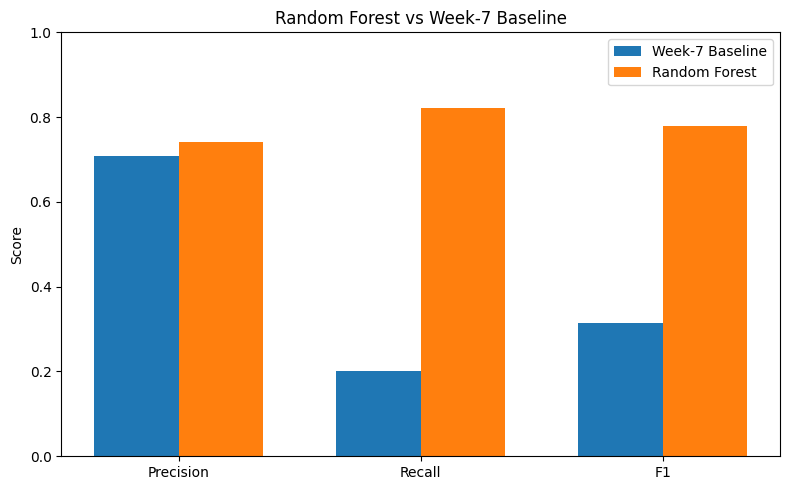

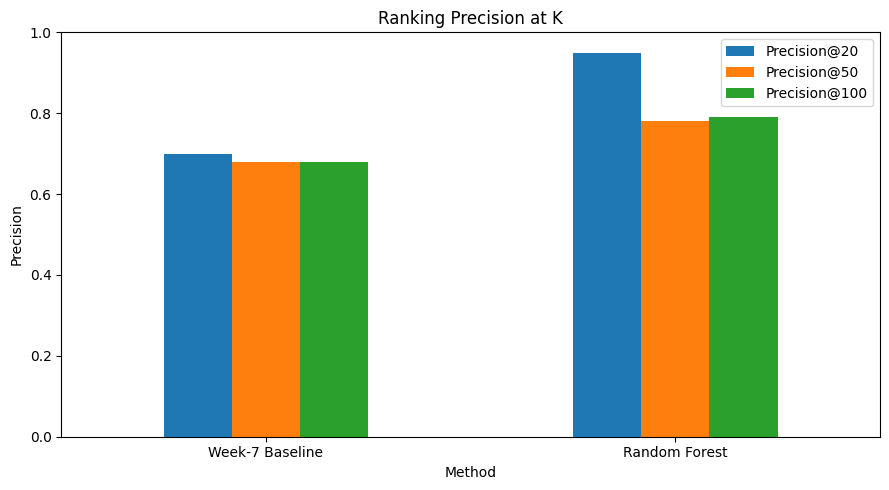

In [59]:
# Section 7 — Create paper-ready result artifacts

import matplotlib.pyplot as plt

# 1. Model vs baseline metrics
metrics_to_plot = ["Precision", "Recall", "F1"]

baseline_values = [
    baseline_results["Precision"],
    baseline_results["Recall"],
    baseline_results["F1"]
]

model_values = [
    rf_results["Precision"],
    rf_results["Recall"],
    rf_results["F1"]
]

x = np.arange(len(metrics_to_plot))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Week-7 Baseline"
)

plt.bar(
    x + width / 2,
    model_values,
    width,
    label="Random Forest"
)

plt.xticks(x, metrics_to_plot)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Random Forest vs Week-7 Baseline")
plt.legend()
plt.tight_layout()
plt.show()


# 2. Precision@K comparison
ranking_plot = ranking_results.set_index("Method")[
    ["Precision@20", "Precision@50", "Precision@100"]
]

ranking_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylim(0, 1)
plt.ylabel("Precision")
plt.title("Ranking Precision at K")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Paper artifacts

The notebook produces two result charts for the deployed research paper:

1. **Random Forest vs Week-7 Baseline**  
   Compares measured precision, recall, and F1 on the same client-grouped test set.

2. **Ranking Precision at K**  
   Compares Precision@20, Precision@50, and Precision@100 for the baseline and Random Forest.

These charts summarize the measured validation results and are intended to support the paper's Results section.

## ML-12 — Closing Materials

### 5-minute demo outline

**0:00–0:45 — Problem**
- Explain the research question.
- Explain that the goal is to prioritize pages for review or refresh.

**0:45–1:30 — Data**
- Explain that the analysis uses the FlyRank pseudonymized full warehouse.
- Explain the pre-outcome feature window and future 30-day decline label.

**1:30–2:30 — Method**
- Explain the Week-7 baseline.
- Explain the Random Forest model.
- Explain the client-grouped validation split and leakage checks.

**2:30–3:30 — Results**
- Show the baseline vs Random Forest metrics.
- Show Precision@20, Precision@50, and Precision@100.
- Explain that the results are measured on the held-out test clients.

**3:30–4:30 — Recommendations**
- Show the Top-20 ranked queue.
- Explain the reason codes and recommended actions.

**4:30–5:00 — Limitations**
- Explain that the model estimates the likelihood of future impression decline based on pre-outcome signals.
- It does not prove that refreshing a page will cause improvement.
- Explain that the output is decision-support for human review.

### Social-post cut

Built a content refresh opportunity scoring workflow using the FlyRank pseudonymized warehouse.

I created a leakage-safe future-decline label, compared the Week-7 heuristic against a Random Forest model using client-grouped validation, and generated a ranked review queue with reason codes and actions.

The result is a decision-support workflow for prioritizing content review — not a claim of causal refresh impact.

### Employer-facing summary

I built an end-to-end ML workflow that uses search-performance signals to prioritize content pages for review based on their measured likelihood of future impression decline. The project included leakage-safe feature engineering, a documented heuristic baseline, Random Forest modeling, client-grouped validation, ranking evaluation, and an action-oriented recommendation queue. The workflow demonstrates practical skills in data engineering, feature design, model evaluation, and translating ML outputs into a usable decision-support process.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
